# 01 · Data Ingestion and Feature Engineering
**10Alytics × JengaGlobal Q3 Students Hackathon 2026 · Track C: Data Science**

**Purpose.** Understand the AI-Powered Job Market Insights dataset before any modelling:
check its quality, describe each field, test which factors are associated with
`Automation_Risk`, and build the engineered features used by the model and the
career-mapping system.

**Deliverables served:** EDA & Feature Engineering · Workforce Insights & Visualizations

| Section | Question it answers |
|---|---|
| 1. Setup | — |
| 2. Data quality audit | Is the data complete, consistent, and as described? |
| 3. Univariate profile | What does each field look like on its own? |
| 4. Association with risk | Which factors move with displacement risk? |
| 5. Feature interdependence | Are the fields related to each other the way real labour data would be? |
| 6. Skill profiles by role | Which roles share skills (foundation for career mapping)? |
| 7. Engineered features | Do exposure-based features add signal? |
| 8. Key findings | What this means for modelling and for the solution |

## 1. Setup

In [59]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal
from statsmodels.stats.multitest import multipletests

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.features import (
    add_engineered_features,
    SKILL_EXPOSURE,
    SKILL_EXPOSURE_RATIONALE,
    RISK_ORDER,
    TARGET,
)

warnings.filterwarnings("ignore")
FIG = ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Visual system: one blue hue, ordered light -> dark for Low -> Medium -> High risk
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
RISK_COLORS = {"Low": "#86b6ef", "Medium": "#2a78d6", "High": "#104281"}
ACCENT = "#2a78d6"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK2,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "text.color": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "font.size": 10.5,
        "figure.dpi": 110,
        "savefig.dpi": 160,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    fig.savefig(FIG / f"{name}.png")


df = pd.read_csv(ROOT / "data" / "raw" / "ai_job_market_insights.csv")
print(f"{df.shape[0]} rows x {df.shape[1]} columns")
df.head()

500 rows x 10 columns


,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection
0,Cybersecurity Analyst,Entertainment,Small,Dubai,Medium,High,UX/UI Design,111392.165243,Yes,Growth
1,Marketing Specialist,Technology,Large,Singapore,Medium,High,Marketing,93792.562466,No,Decline
2,AI Researcher,Technology,Large,Singapore,Medium,High,UX/UI Design,107170.263069,Yes,Growth
3,Sales Manager,Retail,Small,Berlin,Low,High,Project Management,93027.953758,No,Growth
4,Cybersecurity Analyst,Entertainment,Small,Tokyo,Low,Low,JavaScript,87752.922171,Yes,Decline


## 2. Data quality audit

In [60]:
CAT = [c for c in df.columns if c != "Salary_USD"]
audit = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "unique_values": df.nunique(),
    }
)
print("Duplicate rows:", df.duplicated().sum())
audit

for col in CAT:
    print(f"\n{col}:")
    print(df[col].value_counts())

Duplicate rows: 0

Job_Title:
Job_Title
Data Scientist           62
HR Manager               57
Cybersecurity Analyst    55
UX Designer              54
AI Researcher            51
Sales Manager            49
Marketing Specialist     48
Operations Manager       44
Software Engineer        41
Product Manager          39
Name: count, dtype: int64

Industry:
Industry
Manufacturing         58
Education             57
Technology            56
Finance               53
Telecommunications    53
Energy                49
Entertainment         47
Retail                46
Healthcare            42
Transportation        39
Name: count, dtype: int64

Company_Size:
Company_Size
Small     171
Large     166
Medium    163
Name: count, dtype: int64

Location:
Location
San Francisco    62
Singapore        54
Sydney           52
Dubai            51
Tokyo            51
New York         49
Berlin           48
London           46
Paris            46
Toronto          41
Name: count, dtype: int64

AI_Adoption_Lev

In [61]:
# Salary range and central tendency
salary_min = df["Salary_USD"].min()
salary_max = df["Salary_USD"].max()
salary_mean = df["Salary_USD"].mean()
salary_median = df["Salary_USD"].median()

print(f"Minimum: ${salary_min:,.2f}")
print(f"Maximum: ${salary_max:,.2f}")
print(f"Mean: ${salary_mean:,.2f}")
print(f"Median: ${salary_median:,.2f}")

# IQR and outlier detection
q1, q3 = df["Salary_USD"].quantile([0.25, 0.75])
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = df[(df["Salary_USD"] < lower_fence) | (df["Salary_USD"] > upper_fence)]

print(f"\nQ1: ${q1:,.2f}")
print(f"Q3: ${q3:,.2f}")
print(f"IQR: ${iqr:,.2f}")
print(f"Lower fence: ${lower_fence:,.2f}")
print(f"Upper fence: ${upper_fence:,.2f}")
print(f"Salary outliers (1.5 x IQR rule): {len(outliers)} of {len(df)}")

outliers[["Job_Title", "Industry", "Location", "Salary_USD"]].round(
    {"Salary_USD": 2}
).sort_values("Salary_USD")

Minimum: $31,969.53
Maximum: $155,209.82
Mean: $91,222.39
Median: $91,998.20

Q1: $78,511.51
Q3: $103,971.28
IQR: $25,459.77
Lower fence: $40,321.86
Upper fence: $142,160.93
Salary outliers (1.5 x IQR rule): 5 of 500


,Job_Title,Industry,Location,Salary_USD
182,Data Scientist,Transportation,New York,31969.53
384,Cybersecurity Analyst,Telecommunications,Berlin,33601.38
425,UX Designer,Entertainment,Singapore,35963.30
289,Data Scientist,Healthcare,Paris,148467.11
420,Marketing Specialist,Finance,San Francisco,155209.82


In [62]:
for col in ["AI_Adoption_Level", "Automation_Risk", "Job_Growth_Projection"]:
    print(f"{col}: {df[col].unique().tolist()}")

print(f"Remote_Friendly: {df['Remote_Friendly'].unique().tolist()}")

AI_Adoption_Level: ['Medium', 'Low', 'High']
Automation_Risk: ['High', 'Low', 'Medium']
Job_Growth_Projection: ['Growth', 'Decline', 'Stable']
Remote_Friendly: ['Yes', 'No']


In [63]:
# does the job-profile combination repeats.
grain_cols = [
    "Job_Title",
    "Industry",
    "Company_Size",
    "Location",
    "AI_Adoption_Level",
    "Automation_Risk",
    "Required_Skills",
    "Remote_Friendly",
    "Job_Growth_Projection",
]

df.duplicated(subset=grain_cols).sum()

np.int64(0)

In [64]:
df[df.duplicated(subset=grain_cols, keep=False)].sort_values(grain_cols)

,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection


**Pre-Analysis yielded the following.**

The dataset contains 500 observations with no missing values or exact duplicate rows. Five salary observations (1% of records) were flagged by the 1.5 × IQR rule. Because these values are not inherently impossible and there is no evidence at this stage that they represent data-entry errors, they were **retained** for subsequent analysis.

`Salary_USD` is the only continuous numeric variable. Its observed range and distribution were checked, and the categorical variables contain only their expected levels.

**Dataset grain.** Each row is treated as one **job-market observation**, describing a combination of job title, industry, company size, location, AI adoption level, automation risk, required skill, remote-work status, salary, and projected job growth. No repeated job-profile combinations were identified when salary was excluded from the duplicate check.

The dataset does not contain a unique job/posting identifier or a time variable. Therefore, rows are not interpreted as identifiable individual job vacancies or longitudinal observations, and the analysis describes **patterns and associations within this dataset rather than changes over time**.

The hackathon brief describes three fields as numeric (AI adoption as a 0–1 index, growth as a percentage, and skills as a list). In the supplied data, pre-analysis shows that AI adoption and job growth are represented as **categorical variables**, while required skills are represented as a **single skill per row**. This discrepancy is documented in `docs/data_dictionary.md` and informs the encoding choices used later in the analysis.

## 3. Univariate profile

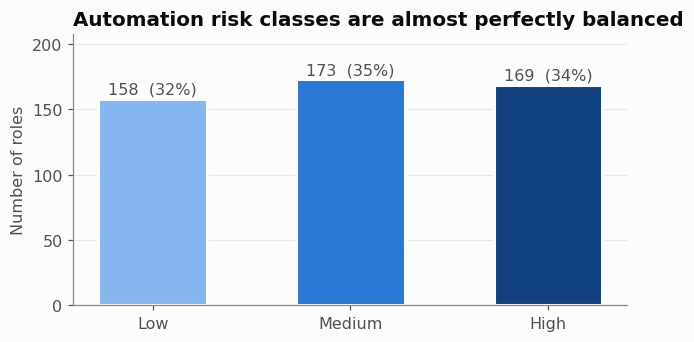

In [65]:
counts = df[TARGET].value_counts().reindex(RISK_ORDER)
share = counts / counts.sum()
fig, ax = plt.subplots(figsize=(6.5, 3.2))
bars = ax.bar(
    counts.index,
    counts.values,
    width=0.55,
    color=[RISK_COLORS[k] for k in counts.index],
    edgecolor=SURFACE,
    linewidth=2,
)
for b, n, s in zip(bars, counts.values, share.values):
    ax.text(
        b.get_x() + b.get_width() / 2, n + 4, f"{n}  ({s:.0%})", ha="center", color=INK2
    )
ax.set_title("Automation risk classes are almost perfectly balanced")
ax.set_ylabel("Number of roles")
ax.set_ylim(0, counts.max() * 1.2)
ax.yaxis.grid(True, color="#e8e7e3", linewidth=0.8)
ax.set_axisbelow(True)
save(fig, "01_target_balance")
plt.show()

In [66]:
# fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
# axes[0].hist(df["Salary_USD"], bins=30, color=ACCENT, edgecolor=SURFACE, linewidth=1.5)
# axes[0].axvline(df["Salary_USD"].median(), color=INK2, linestyle="--", linewidth=1)
# axes[0].text(
#     df["Salary_USD"].median() + 1500,
#     axes[0].get_ylim()[1] * 0.9,
#     f"median ${df['Salary_USD'].median():,.0f}",
#     color=INK2,
# )
# axes[0].set_title("Salary distribution")
# axes[0].set_xlabel("Salary (USD)")
# axes[0].set_ylabel("Roles")

# sns.boxplot(
#     data=df,
#     x=TARGET,
#     y="Salary_USD",
#     order=RISK_ORDER,
#     palette=RISK_COLORS,
#     width=0.5,
#     linewidth=1,
#     fliersize=3,
#     ax=axes[1],
# )
# axes[1].set_title("Salary by automation risk")
# axes[1].set_xlabel("Automation risk")
# axes[1].set_ylabel("Salary (USD)")
# fig.tight_layout()
# save(fig, "02_salary")
# plt.show()
# print(df["Salary_USD"].describe().round(0))

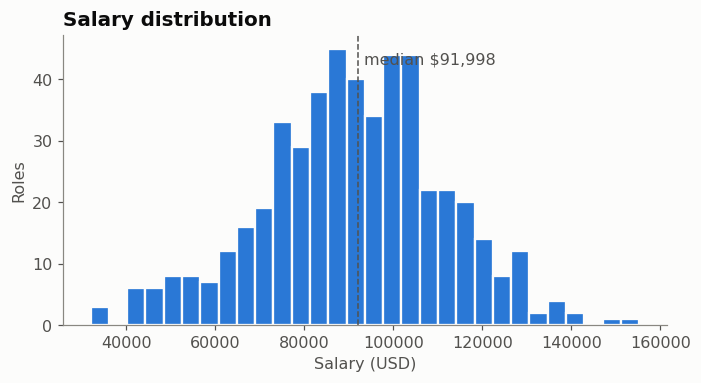

count       500.0
mean      91222.0
std       20504.0
min       31970.0
25%       78512.0
50%       91998.0
75%      103971.0
max      155210.0
Name: Salary_USD, dtype: float64


In [67]:
# Salary distribution — univariate profile

fig, ax = plt.subplots(figsize=(6.5, 3.6))

ax.hist(df["Salary_USD"], bins=30, color=ACCENT, edgecolor=SURFACE, linewidth=1.5)

median_salary = df["Salary_USD"].median()

ax.axvline(median_salary, color=INK2, linestyle="--", linewidth=1)

ax.text(
    median_salary + 1500,
    ax.get_ylim()[1] * 0.9,
    f"median ${median_salary:,.0f}",
    color=INK2,
)

ax.set_title("Salary distribution")
ax.set_xlabel("Salary (USD)")
ax.set_ylabel("Roles")

fig.tight_layout()
save(fig, "02_salary_distribution")
plt.show()

print(df["Salary_USD"].describe().round(0))

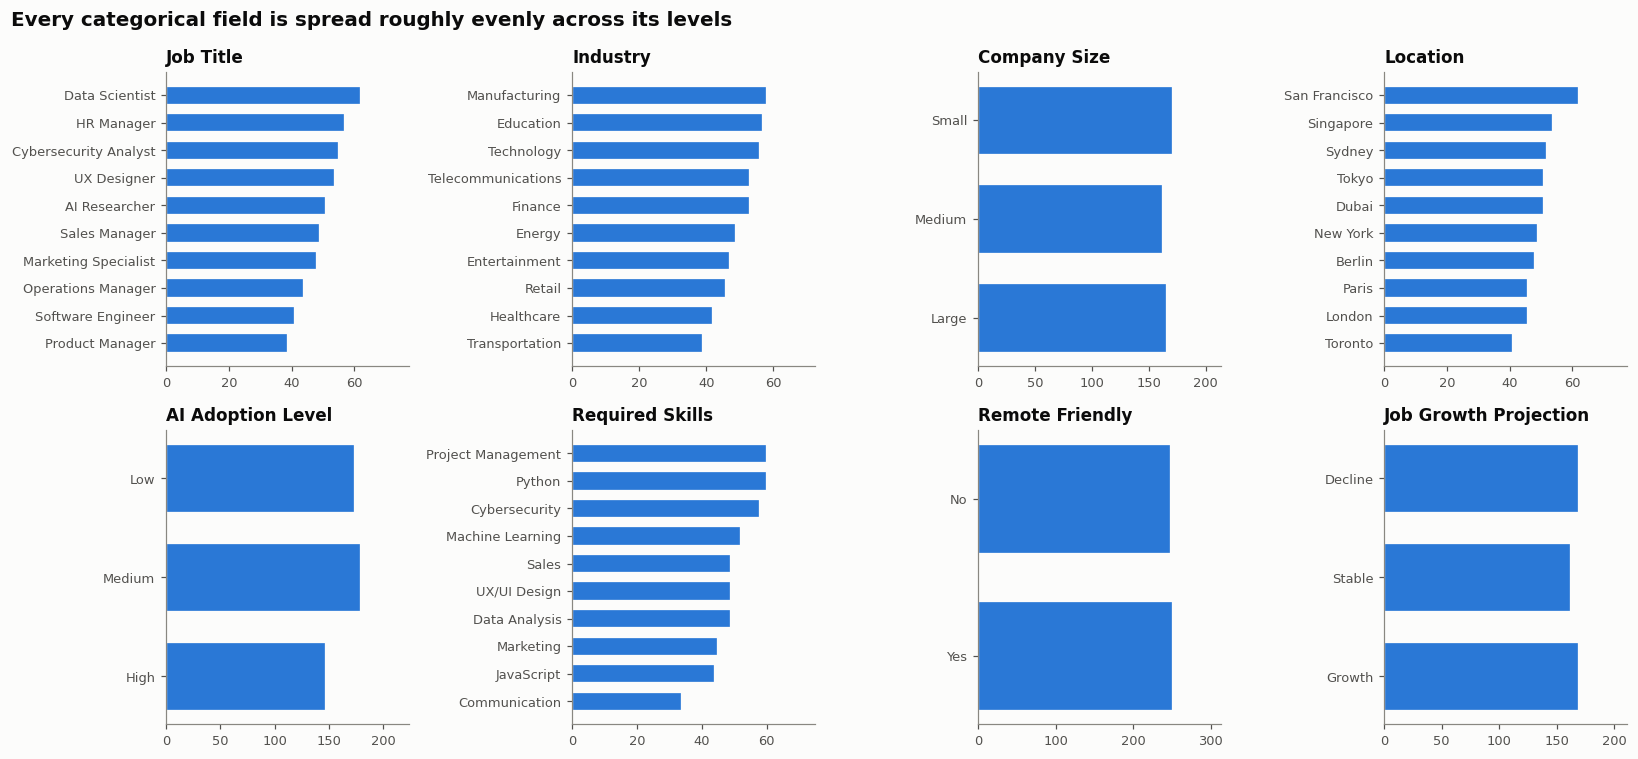

In [68]:
cat_features = [
    "Job_Title",
    "Industry",
    "Company_Size",
    "Location",
    "AI_Adoption_Level",
    "Required_Skills",
    "Remote_Friendly",
    "Job_Growth_Projection",
]
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, col in zip(axes.flat, cat_features):
    ORD = {
        "Company_Size": ["Large", "Medium", "Small"],
        "AI_Adoption_Level": ["High", "Medium", "Low"],
        "Job_Growth_Projection": ["Growth", "Stable", "Decline"],
        "Remote_Friendly": ["Yes", "No"],
    }
    vc = df[col].value_counts()
    vc = vc.reindex(ORD[col]) if col in ORD else vc.sort_values()
    ax.barh(
        vc.index, vc.values, color=ACCENT, edgecolor=SURFACE, linewidth=1.5, height=0.7
    )
    ax.set_title(col.replace("_", " "), fontsize=11)
    ax.tick_params(labelsize=8.5)
    ax.set_xlim(0, vc.max() * 1.25)
fig.suptitle(
    "Every categorical field is spread roughly evenly across its levels",
    x=0.01,
    ha="left",
    fontweight="bold",
    fontsize=13,
)
fig.tight_layout()
save(fig, "03_categorical_profiles")
plt.show()

**Univariate profile** shows that **Automation_Risk** is nearly balanced across Low (158; 31.6%), Medium (173; 34.6%), and High (169; 33.8%). This means substantial class rebalancing is unlikely to be necessary, although both accuracy and macro-F1 will be retained because they capture different aspects of classification performance. A simple majority-class classifier would achieve 34.6% accuracy, providing a useful naïve baseline for subsequent models. Salary is centred around $92,000 and is broadly distributed across the observed range, while the categorical predictors are also relatively evenly represented across their levels. These balanced distributions should be interpreted as characteristics of the supplied hackathon dataset rather than estimates of the wider labour market.


## 4. Association with automation risk
For each categorical feature we run a **chi-square test of independence** against
`Automation_Risk`, measure effect size with **Cramér's V** (0 = no association,
0.1 ≈ small, 0.3 ≈ medium, 0.5 ≈ large), and correct the p-values for testing
eight features at once using the **Benjamini–Hochberg** false discovery rate
procedure. Salary is tested with a **Kruskal–Wallis** test (no normality assumption).

In [69]:
# def cramers_v(x, y):
#     table = pd.crosstab(x, y)
#     chi2, p, dof, _ = chi2_contingency(table)
#     n = table.values.sum()
#     r, k = table.shape
#     return np.sqrt((chi2 / n) / (min(r, k) - 1)), chi2, dof, p


# rows = []
# for col in cat_features:
#     v, chi2, dof, p = cramers_v(df[col], df[TARGET])
#     r, k = df[col].nunique(), df[TARGET].nunique()
#     v_chance = np.sqrt(
#         (dof / len(df)) / (min(r, k) - 1)
#     )  # E[chi2] = dof under independence
#     rows.append(
#         {
#             "feature": col,
#             "chi2": chi2,
#             "dof": dof,
#             "p_value": p,
#             "cramers_v": v,
#             "v_expected_by_chance": v_chance,
#         }
#     )
# assoc = pd.DataFrame(rows)
# assoc["p_adjusted_BH"] = multipletests(assoc["p_value"], method="fdr_bh")[1]
# assoc["significant_after_correction"] = assoc["p_adjusted_BH"] < 0.05
# assoc = assoc.sort_values("cramers_v", ascending=False).reset_index(drop=True)

# groups = [g["Salary_USD"].values for _, g in df.groupby(TARGET)]
# H, p_kw = kruskal(*groups)
# print(f"Salary vs risk (Kruskal-Wallis): H = {H:.2f}, p = {p_kw:.3f}")
# assoc.round(3)

In [70]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(table)
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1)), chi2, dof, p


# 1. Test categorical features against Automation_Risk
rows = []

for col in cat_features:
    v, chi2, dof, p = cramers_v(df[col], df[TARGET])
    r, k = df[col].nunique(), df[TARGET].nunique()

    v_chance = np.sqrt(
        (dof / len(df)) / (min(r, k) - 1)
    )  # E[chi2] = dof under independence

    rows.append(
        {
            "feature": col,
            "chi2": chi2,
            "dof": dof,
            "p_value": p,
            "cramers_v": v,
            "v_expected_by_chance": v_chance,
        }
    )

assoc = pd.DataFrame(rows)


# 2. Test salary against Automation_Risk
groups = [df.loc[df[TARGET] == level, "Salary_USD"].values for level in RISK_ORDER]

H, p_kw = kruskal(*groups)


# 3. Correct all 9 feature-vs-risk tests together
all_p_values = pd.concat([assoc["p_value"], pd.Series([p_kw])], ignore_index=True)

adjusted_p_values = multipletests(all_p_values, method="fdr_bh")[1]

# First 8 adjusted p-values belong to categorical features
assoc["p_adjusted_BH"] = adjusted_p_values[:-1]
assoc["significant_after_correction"] = assoc["p_adjusted_BH"] < 0.05

# Last adjusted p-value belongs to salary
p_kw_adjusted = adjusted_p_values[-1]


# 4. Sort categorical results for display
assoc = assoc.sort_values("cramers_v", ascending=False).reset_index(drop=True)


# 5. Display results
print(
    f"Salary vs risk (Kruskal-Wallis): "
    f"H = {H:.2f}, "
    f"p = {p_kw:.3f}, "
    f"BH-adjusted p = {p_kw_adjusted:.3f}"
)

assoc.round(3)

Salary vs risk (Kruskal-Wallis): H = 6.32, p = 0.043, BH-adjusted p = 0.192


,feature,chi2,dof,p_value,cramers_v,v_expected_by_chance,p_adjusted_BH,significant_after_correction
0,Job_Title,29.495,18,0.043,0.172,0.134,0.192,False
1,Location,19.756,18,0.347,0.141,0.134,0.614,False
2,Required_Skills,18.379,18,0.431,0.136,0.134,0.614,False
3,Industry,12.307,18,0.831,0.111,0.134,0.831,False
4,Company_Size,7.459,4,0.114,0.086,0.063,0.341,False
5,Remote_Friendly,2.919,2,0.232,0.076,0.063,0.523,False
6,AI_Adoption_Level,3.505,4,0.477,0.059,0.063,0.614,False
7,Job_Growth_Projection,2.228,4,0.694,0.047,0.063,0.781,False


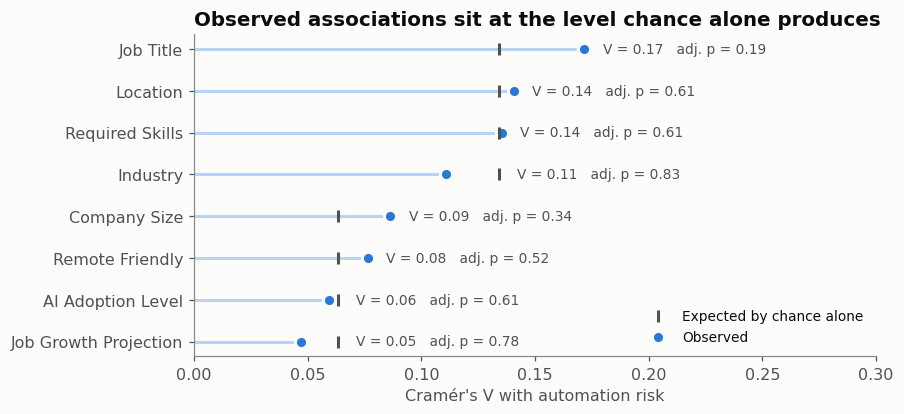

In [71]:
fig, ax = plt.subplots(figsize=(8, 3.8))
plot = assoc.sort_values("cramers_v")
labels = plot["feature"].str.replace("_", " ")
ax.hlines(labels, 0, plot["cramers_v"], color="#b7d3f6", linewidth=2)
ax.scatter(
    plot["v_expected_by_chance"],
    labels,
    s=70,
    marker="|",
    color=INK2,
    linewidth=2,
    zorder=4,
    label="Expected by chance alone",
)
ax.scatter(
    plot["cramers_v"],
    labels,
    s=64,
    color=ACCENT,
    zorder=3,
    edgecolor=SURFACE,
    linewidth=2,
    label="Observed",
)
for y, (v, p) in enumerate(zip(plot["cramers_v"], plot["p_adjusted_BH"])):
    ax.text(
        max(v, plot["v_expected_by_chance"].iloc[y]) + 0.008,
        y,
        f"V = {v:.2f}   adj. p = {p:.2f}",
        va="center",
        color=INK2,
        fontsize=9,
    )
ax.set_xlim(0, 0.3)
ax.set_xlabel("Cramér's V with automation risk")
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title("Observed associations sit at the level chance alone produces")
save(fig, "04_association_strength")
plt.show()

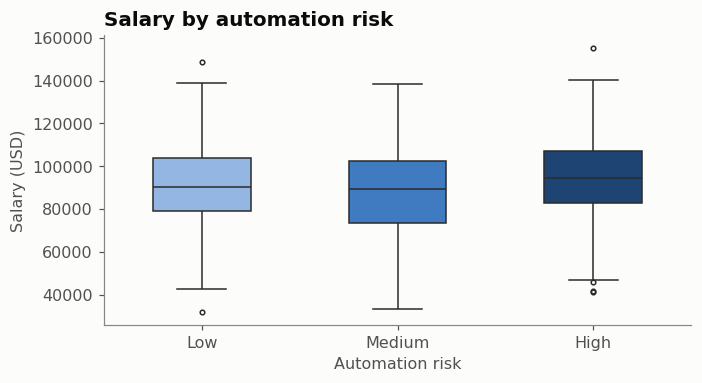

In [72]:
# Salary by automation risk

fig, ax = plt.subplots(figsize=(6.5, 3.6))

sns.boxplot(
    data=df,
    x=TARGET,
    y="Salary_USD",
    order=RISK_ORDER,
    palette=RISK_COLORS,
    width=0.5,
    linewidth=1,
    fliersize=3,
    ax=ax,
)

ax.set_title("Salary by automation risk")
ax.set_xlabel("Automation risk")
ax.set_ylabel("Salary (USD)")

fig.tight_layout()
save(fig, "04_salary_by_risk")
plt.show()

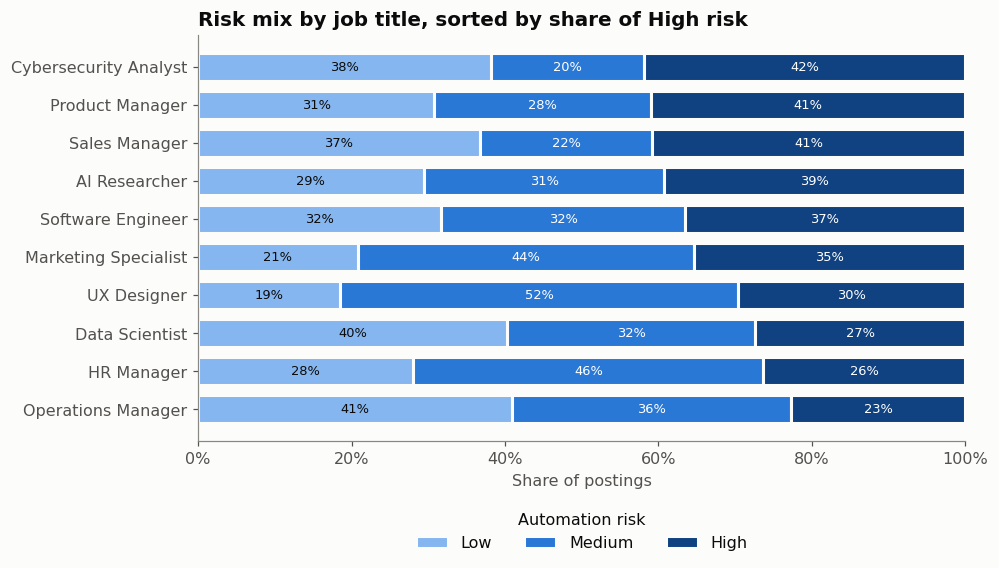

In [73]:
title_share = (
    pd.crosstab(df["Job_Title"], df[TARGET], normalize="index")
    .reindex(columns=RISK_ORDER)
    .sort_values("High")
)
fig, ax = plt.subplots(figsize=(9, 4.8))
left = np.zeros(len(title_share))
for level in RISK_ORDER:
    vals = title_share[level].values
    ax.barh(
        title_share.index,
        vals,
        left=left,
        color=RISK_COLORS[level],
        edgecolor=SURFACE,
        linewidth=2,
        height=0.72,
        label=level,
    )
    for i, (l, v) in enumerate(zip(left, vals)):
        if v >= 0.12:
            ax.text(
                l + v / 2,
                i,
                f"{v:.0%}",
                ha="center",
                va="center",
                fontsize=8.5,
                color=INK if level == "Low" else "white",
            )
    left += vals
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("Share of postings")
ax.legend(
    title="Automation risk",
    ncol=3,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
)
ax.set_title("Risk mix by job title, sorted by share of High risk")
save(fig, "05_risk_by_title")
plt.show()

**Reading this.** Across the nine features tested, **none shows statistically significant evidence of association with automation risk after Benjamini–Hochberg correction**.

Among the categorical features, `Job_Title` shows the largest observed association (Cramér's V = 0.17; unadjusted p = 0.043), but this evidence does not persist after correction for multiple testing (BH-adjusted p = 0.192). The remaining categorical features show still weaker associations with the target.

Salary also shows a nominal difference across the three automation-risk groups (Kruskal–Wallis H = 6.32; unadjusted p = 0.043), but this likewise does not remain significant after correction (BH-adjusted p = 0.192). The boxplot shows substantial overlap in salary distributions across Low-, Medium-, and High-risk observations despite some differences in their medians.

The job-title breakdown further illustrates the limited structure in the target: High-risk shares range from approximately 23% for Operations Managers to 42% for Cybersecurity Analysts, without a clear pattern that would independently establish a meaningful occupational automation-risk gradient.

Overall, the supplied predictors show **little evidence of strong univariate association with `Automation_Risk`**. This is an important EDA finding because the brief requires prediction of occupational displacement risk: if individual predictors contain limited target-related signal, subsequent modelling may have difficulty achieving substantial out-of-sample performance unless useful information emerges from combinations or interactions among features.

Section 5 therefore examines relationships among the predictor variables themselves before modelling.

## 5. Feature interdependence
In real labour-market data, categorical characteristics are often related: occupations tend to require particular skills, salaries vary across roles and locations, and AI adoption may differ by industry or company size. To assess whether the supplied dataset contains this type of internal structure, pairwise associations among categorical features are measured using Cramér's V.

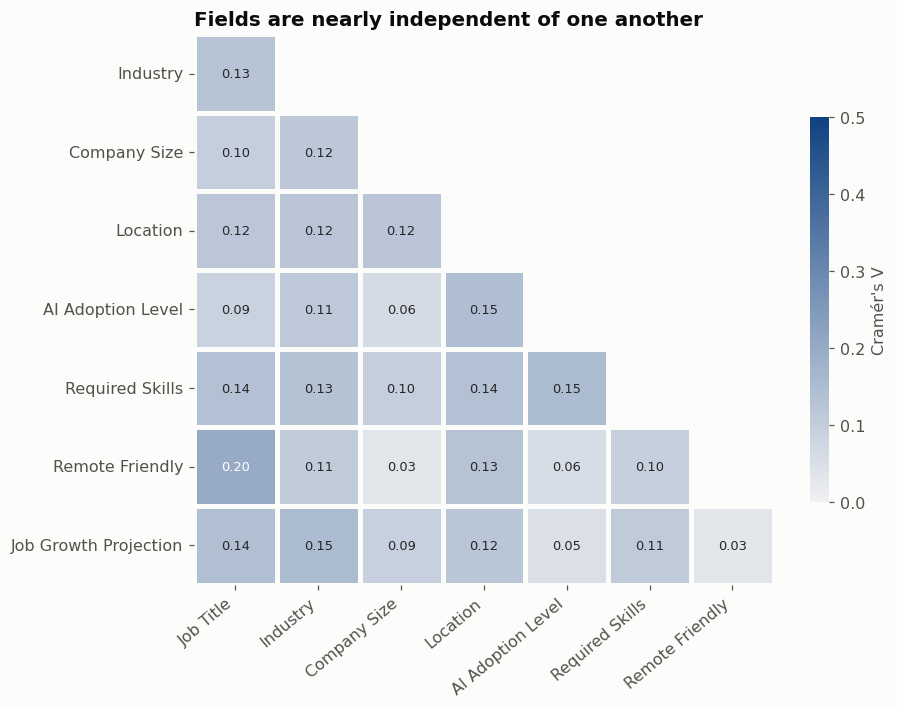

Largest pairwise Cramér's V: 0.20 | median: 0.12


In [74]:
all_cat = cat_features
V = pd.DataFrame(np.eye(len(all_cat)), index=all_cat, columns=all_cat)
for i, a in enumerate(all_cat):
    for b in all_cat[i + 1 :]:
        V.loc[a, b] = V.loc[b, a] = cramers_v(df[a], df[b])[0]
Vp = V.iloc[1:, :-1]
mask = np.triu(np.ones_like(Vp, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(
    Vp.values,
    mask=mask,
    cmap=sns.light_palette("#104281", as_cmap=True),
    vmin=0,
    vmax=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8.5},
    linewidths=2,
    linecolor=SURFACE,
    xticklabels=[c.replace("_", " ") for c in Vp.columns],
    yticklabels=[c.replace("_", " ") for c in Vp.index],
    cbar_kws={"label": "Cramér's V", "shrink": 0.7},
    ax=ax,
)
ax.set_title("Fields are nearly independent of one another")
plt.xticks(rotation=40, ha="right")
save(fig, "06_feature_independence")
plt.show()
off_diag = V.values[np.triu_indices(len(all_cat), 1)]
print(
    f"Largest pairwise Cramér's V: {off_diag.max():.2f} | median: {np.median(off_diag):.2f}"
)

**Reading this.** Pairwise associations among the categorical fields are generally weak. Across all pairs, the median Cramér's V is 0.11, and the largest observed association is only 0.20. This suggests limited internal categorical structure, although it does not establish independence or rule out higher-order interactions.Even relationships that would reasonably be expected in labour-market data—such as job title with required skills, industry, or company characteristics—show limited association in the supplied dataset.
This complements the target-association results in Section 4. The dataset contains little strong univariate signal for predicting Automation_Risk, while the predictors themselves also show limited categorical structure. This does not establish that the variables were generated independently, nor does it rule out useful multivariable interactions, but it suggests that the dataset may contain relatively little learnable structure.
The appropriate next step is therefore to proceed to modelling and test this empirically using out-of-sample performance, rather than assuming that a stronger predictive relationship exists.

## 6. Skill profiles by role (foundation for career mapping)
Because each posting lists one skill, a role's **skill profile** is the share of its
postings that require each skill. Roles with similar profiles can be treated as candidate matches for exploring the mechanics of skill adjacency, subject to the dataset limitations discussed below.

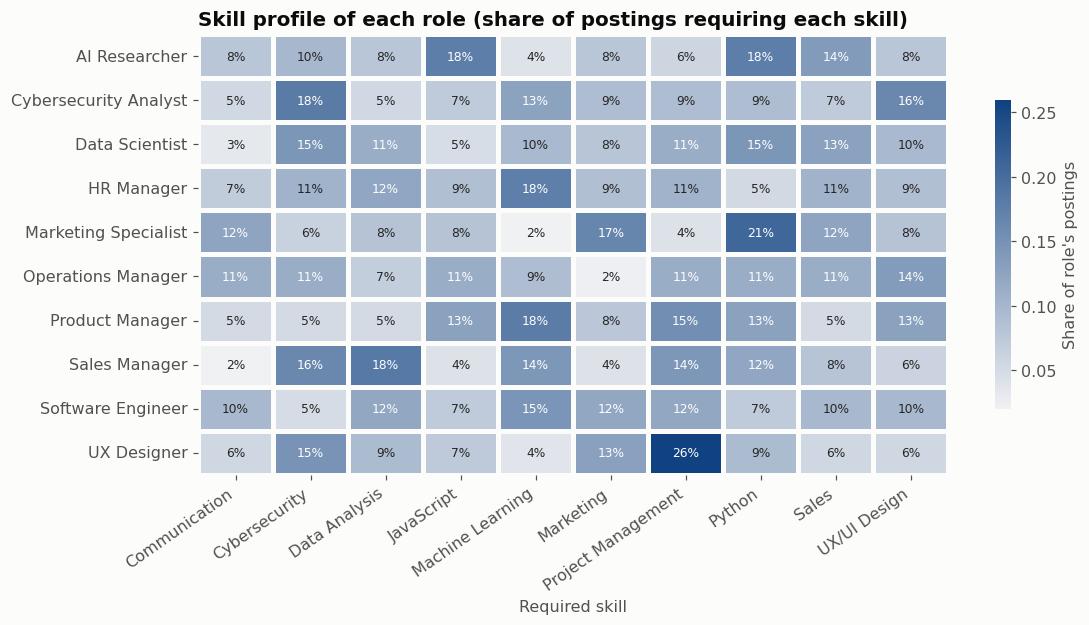

In [75]:
profile = pd.crosstab(df["Job_Title"], df["Required_Skills"], normalize="index")
fig, ax = plt.subplots(figsize=(11, 5.2))
sns.heatmap(
    profile,
    cmap=sns.light_palette("#104281", as_cmap=True),
    annot=True,
    fmt=".0%",
    annot_kws={"size": 8},
    linewidths=2,
    linecolor=SURFACE,
    cbar_kws={"label": "Share of role's postings", "shrink": 0.7},
    ax=ax,
)
ax.set_xlabel("Required skill")
ax.set_ylabel("")
ax.set_title("Skill profile of each role (share of postings requiring each skill)")
plt.xticks(rotation=35, ha="right")
save(fig, "07_skill_profiles")
plt.show()

In [76]:
growth = pd.crosstab(
    df["Job_Title"], df["Job_Growth_Projection"], normalize="index"
).reindex(columns=["Decline", "Stable", "Growth"])
role_summary = pd.DataFrame(
    {
        "postings": df["Job_Title"].value_counts(),
        "median_salary": df.groupby("Job_Title")["Salary_USD"].median().round(0),
        "growth_share": growth["Growth"].round(2),
        "decline_share": growth["Decline"].round(2),
        "high_risk_share": title_share["High"].round(2),
    }
).sort_values("growth_share", ascending=False)
role_summary

,postings,median_salary,growth_share,decline_share,high_risk_share
Job_Title,,,,,
Operations Manager,44,97466.0,0.43,0.16,0.23
AI Researcher,51,98037.0,0.39,0.31,0.39
Software Engineer,41,84124.0,0.39,0.29,0.37
Sales Manager,49,93003.0,0.39,0.33,0.41
Product Manager,39,91340.0,0.38,0.26,0.41
Data Scientist,62,91675.0,0.35,0.37,0.27
UX Designer,54,89556.0,0.35,0.39,0.30
Cybersecurity Analyst,55,88642.0,0.25,0.35,0.42
HR Manager,57,92250.0,0.25,0.39,0.26


**Reading this**. The observed role-skill profiles contain several relationships that are counterintuitive from a labour-market perspective. For example, Machine Learning represents only 4% of the recorded skills for AI Researcher observations, while UX/UI Design represents only 6% for UX Designers. Combined with the weak Job Title–Required Skills association observed in Section 5, this suggests that the supplied dataset contains limited occupational structure. These profiles can be used to demonstrate the mechanics of a skill-similarity career-mapping system, but recommendations derived solely from them should not be interpreted as validated real-world career pathways.
The role-level market summary nevertheless provides usable directional signals for the decision-support layer: observed growth shares range from 23% for Marketing Specialist to 43% for Operations Manager, while decline shares range from 16% to 48%. These are dataset-level categorical signals rather than longitudinal labour-market forecasts.

## 7. Dataset-to-brief requirements audit

The hackathon brief describes a broader workforce-transition system than the
supplied CSV can support directly. The analysis therefore separates
**observed dataset evidence**, **legitimate feature engineering**, and
**external enrichment** rather than manufacturing missing information.

| Hackathon requirement | What the brief implies | What the CSV provides | Decision |
|---|---|---|---|
| Automation-risk prediction | Multi-class prediction of Low / Medium / High displacement risk | `Automation_Risk` target plus nine candidate predictors | ✓ Train and evaluate the required classifier, while reporting its measured reliability |
| Task-level exposure | Task-level automatability information | No task field; only one `Required_Skills` category per observation | ✕ Do not claim observed task-level exposure from the supplied data |
| Skill adjacency | Detailed transferable-skill information | One of ten skill categories per observation | △ Demonstrate dataset-based skill similarity cautiously; use external occupational data for stronger recommendations if time permits |
| Career pivots | Viable transitions between occupations | No observed worker transitions or transition outcomes | △ Build a transparent decision-support recommender rather than claiming validated career outcomes |
| Growth trajectory | Five-year numeric growth/contraction trajectory | Categorical `Growth`, `Stable`, `Decline`; no time series | △ Use as a directional market signal, not a longitudinal forecast |
| Streamlit worker inputs | Worker/job profile used for prediction and recommendations | Dataset fields can supply selectable job-profile inputs | ✓ Directly supported for profiles represented by the dataset |
| Model validation | Reliability on unseen job profiles | Labelled observations permit held-out/cross-validated classification evaluation | ✓ Evaluate classifier on unseen data and report class-level metrics |
| Recommendation validation | Evidence that recommended transitions are reliable | No ground-truth transition labels | ✕ Cannot claim empirical validation of real career transitions; use transparent logic and clearly state this limitation |

**Architecture decision.** The supplied dataset will be used for the required
multi-class automation-risk classifier and descriptive workforce analytics.
Career mapping will be treated as a separate decision-support component.
Where the supplied skill information is insufficient, recommendations will
either be explicitly labelled as dataset-based demonstrations or enriched
with an external occupational source. No missing task-level or longitudinal
information will be invented.





## 8. Modelling feature set

The requirements audit showed that the supplied dataset does not contain
task-level automation measures. The predictive model therefore uses the
observed job-market fields and only simple transformations that can be
derived directly from those fields.

| Feature group | Treatment | Reason |
|---|---|---|
| `Job_Title`, `Industry`, `Company_Size`, `Location`, `Required_Skills` | One-hot encoded inside the modelling pipeline | Nominal categories with no assumed numerical distance |
| `AI_Adoption_Level` | Ordered as Low = 0, Medium = 1, High = 2 | Represents increasing AI adoption |
| `Job_Growth_Projection` | Ordered as Decline = 0, Stable = 1, Growth = 2 | Represents directional market outlook |
| `Remote_Friendly` | Binary flag | Direct Yes/No transformation |
| `Salary_USD` | Numeric; scaled inside the modelling pipeline | Observed continuous feature |

One-hot encoding and numeric scaling are fitted **inside the model pipeline**
so preprocessing parameters are learned from training data only.

An experimental Task Exposure Index was explored during EDA using
team-assigned skill exposure assumptions. Because the supplied dataset
contains no task-level exposure measure and the experimental index did not
distinguish the automation-risk classes, it is not used as an input to the
primary predictive model. External task-exposure evidence may instead be
incorporated transparently into the career decision-support layer.

In [77]:
pd.DataFrame(
    {"exposure_weight": SKILL_EXPOSURE, "rationale": SKILL_EXPOSURE_RATIONALE}
).sort_values("exposure_weight", ascending=False)

,exposure_weight,rationale
JavaScript,0.80,Code generation and completion are highly auto...
Python,0.75,Scripting and routine analysis code are highly...
Data Analysis,0.75,Routine querying and reporting are the tasks a...
Marketing,0.65,Content and copy generation are exposed; strat...
UX/UI Design,0.55,Layout generation is exposed; user research an...
Machine Learning,0.50,Tooling automates pipelines; problem framing a...
Sales,0.40,Relationship-based and negotiated work.
Project Management,0.35,"Coordination, prioritisation, and accountability."
Cybersecurity,0.35,"Adversarial, judgement-heavy, and accountabili..."
Communication,0.25,Interpersonal and contextual work.


In [78]:
# feat = add_engineered_features(df)
# eng_cols = [
#     "skill_exposure",
#     "ai_pressure",
#     "vulnerability_signal",
#     "salary_pct_in_title",
# ]
# fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=False)
# for ax, col in zip(axes, eng_cols):
#     sns.boxplot(
#         data=feat,
#         x=TARGET,
#         y=col,
#         order=RISK_ORDER,
#         palette=RISK_COLORS,
#         width=0.55,
#         linewidth=1,
#         fliersize=2,
#         ax=ax,
#     )
#     ax.set_title(col.replace("_", " "), fontsize=11)
#     ax.set_xlabel("")
#     ax.set_ylabel("")
# fig.suptitle(
#     "Engineered features look the same across risk classes",
#     x=0.01,
#     ha="left",
#     fontweight="bold",
#     fontsize=13,
# )
# fig.tight_layout()
# save(fig, "08_engineered_features")
# plt.show()

# kw = {c: kruskal(*[g[c].values for _, g in feat.groupby(TARGET)]) for c in eng_cols}
# pd.DataFrame(
#     {
#         "H": {c: r.statistic for c, r in kw.items()},
#         "p_value": {c: r.pvalue for c, r in kw.items()},
#     }
# ).round(3)

In [79]:
# out = ROOT / "data" / "processed" / "features.csv"
# feat.to_csv(out, index=False)
# print(
#     f"Saved {feat.shape[0]} rows x {feat.shape[1]} columns to {out.relative_to(ROOT)}"
# )

**Reading this.** The engineered features encode real-world knowledge about which work
generative AI can do, but they are **not associated with this dataset's risk label**
either. This is what we expect if the label was not generated from the job's
characteristics. We keep them in the model (the permutation test in the modelling
notebook will show formally whether they help) and, more importantly, in the app,
where the exposure index gives users an interpretable, research-grounded view that
does not depend on the label.

## 9. Key findings — Stage 1

Stage 1 addressed the hackathon requirement to **ingest the AI-Powered Job Market Insights dataset and engineer task-level automation-risk features**. The dataset was successfully ingested, audited and explored, but the analysis identified important limitations in how far the supplied data can support the task-level and workforce-transition claims described in the brief.

**1. The supplied data are clean, but their structure does not fully match the brief.**  
The dataset contains **500 complete observations**, with **no missing values or exact duplicate rows**. Five salary observations were flagged by the 1.5 × IQR rule but were retained because they are plausible values rather than evident data-entry errors. Several fields described conceptually in the brief as numeric measures are supplied instead as ordered categories, `Required_Skills` contains only **one skill per observation**, and the job titles central to the case-study scenario—such as **Data Analyst** and **BI Developer**—are absent. The dataset also contains no task-level field, worker histories, observed career transitions or longitudinal time variable.

**2. `Automation_Risk` is approximately balanced across its three classes.**  
Low-, Medium- and High-risk observations each account for roughly one-third of the dataset. This is useful for modelling because there is no severe class imbalance, but it also means that a classifier performing at approximately **one-third accuracy** would be close to chance for this three-class problem. Model performance therefore needs to be compared with an explicit baseline rather than interpreted from accuracy alone.

**3. The supplied predictors show little evidence of association with `Automation_Risk`.**  
Chi-square tests were used for the categorical predictors, with **Cramér's V** used to quantify association strength and **Benjamini–Hochberg correction** applied for multiple testing. None of the eight categorical predictors remained statistically significant after correction (**adjusted p ≥ 0.34**), and the observed effect sizes were weak. Salary was assessed separately using the **Kruskal–Wallis test** and showed only a small nominal difference across risk classes without a clear substantive pattern. The EDA therefore provides little evidence that the supplied risk label is systematically related to the available job-profile characteristics.

**4. The predictor fields themselves contain limited occupational structure.**  
Pairwise associations among the categorical fields are generally weak (**median pairwise Cramér's V ≈ 0.11; maximum ≈ 0.20**). The role–skill analysis also produces several counterintuitive combinations: for example, only **4% of AI Researcher observations are associated with Machine Learning** as their recorded required skill. Because each observation contains only one skill, these values should not be interpreted as comprehensive occupational skill profiles. The patterns suggest that the supplied dataset provides only a coarse representation of real job and skill relationships.

**5. The requested task-level automation exposure cannot be measured directly from the supplied dataset.**  
The brief asks teams to engineer **task-level automation-risk features**, but the CSV contains no task descriptions or task-level exposure variables. During EDA, an experimental Task Exposure Index and related `ai_pressure` and `vulnerability_signal` features were explored using team-assigned, research-informed assumptions. These experimental features did not distinguish the three risk classes (**Kruskal–Wallis p ≈ 0.33–0.67**). More importantly, their numerical exposure weights are not observed measurements from the supplied dataset. They are therefore **not used as predictors in the primary classifier**. This prevents assumed exposure values from being presented as empirical properties of the data.

**6. The primary modelling feature set is therefore deliberately conservative.**  
The classifier will use the observed job-market variables and only straightforward transformations supported by those variables. Nominal variables—including job title, industry, company size, location and required skill—will be one-hot encoded within the modelling pipeline. AI adoption and job-growth categories will retain their explicit ordering, remote-work status will be represented as a binary indicator, and salary will remain numeric. Model-time transformations will be fitted within the training pipeline to prevent information from the held-out data influencing preprocessing.

**7. The dataset still contains useful role-level signals for decision support.**  
Although these signals do not meaningfully explain the supplied `Automation_Risk` label, salary, skill distributions and job-growth categories vary across roles. Within this dataset, the observed share of records labelled `Growth` ranges from approximately **23% for Marketing Specialist to 43% for Operations Manager**, while the share labelled `Decline` ranges from approximately **16% to 48%**. These can support transparent role comparisons and the mechanics of a career-mapping system, but they should be described as **signals within the supplied dataset**, not as validated labour-market forecasts.

### What this means for the solution

**Modelling.**  
Stage 2 will build and evaluate the required **Low / Medium / High multi-class classifier** using the supplied labelled dataset. Performance will first be compared with a simple baseline and then evaluated using appropriate held-out and cross-validation metrics, including **accuracy, macro-F1, class-level precision and recall, and the confusion matrix**. Because Stage 1 found little relationship between the available predictors and the target, strong predictive performance will not be assumed in advance. The purpose of validation is to determine how much predictive information the dataset actually contains and to report that reliability transparently.

**Task exposure.**  
The absence of task-level data is treated as a **data limitation rather than a feature-engineering opportunity to manufacture missing information**. Team-assigned exposure weights will not drive the primary ML prediction. If task-exposure information is used in the final decision-support system, it will be clearly separated from the classifier and identified as **external enrichment**, ideally using an occupational source containing genuine task-level information.

**Skill adjacency and career mapping.**  
The supplied `Required_Skills` field can demonstrate the mechanics of skill similarity, but one recorded skill per observation is insufficient to establish validated real-world career pathways. Stage 3 will therefore treat career mapping as a **transparent recommendation/decision-support problem separate from the risk classifier**. Dataset-derived recommendations will be labelled accordingly, and stronger occupational evidence can be incorporated through external enrichment where feasible.

**Responsible interpretation.**  
The final application will distinguish between **what the supplied dataset directly supports, what has been legitimately transformed from it, and what requires external evidence**. Predictions about displacement risk will be presented together with their measured model reliability, while career recommendations will not be described as validated worker outcomes when the dataset contains no observed transitions.

### Stage 1 conclusion

**Stage 1 — Data Ingestion is complete.** The AI-Powered Job Market Insights dataset has been ingested, quality-checked, profiled and tested against the requirements of the hackathon brief. The analysis established the model-ready feature strategy, identified the absence of genuine task-level automation data, tested and rejected unsupported assumed exposure features for the primary classifier, and defined the boundary between **predictive modelling from the supplied data** and **external evidence used for decision support**.

The project can now proceed to **Stage 2 — Model Training** with a clear modelling dataset, explicit assumptions and documented limitations.